# MI Detection: 92% Accuracy


---
## CELL 1 — Install Libraries

In [1]:
!pip install neurokit2 wfdb scikit-learn xgboost shap gradio pandas numpy matplotlib seaborn PyWavelets imblearn -q
print('All libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
All libraries installed!


---
## CELL 2 — Import Everything

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import neurokit2 as nk
import wfdb
import shap
import pywt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

from imblearn.over_sampling import SMOTE

from scipy.stats import skew, kurtosis, entropy

print('✓ All imports successful!')

✓ All imports successful!


---
## CELL 3 — Download PTB-XL Dataset

In [ ]:
import ast
import wfdb

print('Loading dataset metadata...')
df = pd.read_csv(
    'https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv',
    index_col='ecg_id'
)

scp_df = pd.read_csv('https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv', index_col=0)
scp_diag = scp_df[scp_df['diagnostic'] == 1]

def get_superclass(scp_codes_str):
    try:
        scp_dict = ast.literal_eval(scp_codes_str)
        for code, confidence in scp_dict.items():
            if code in scp_diag.index and confidence > 0:
                sc = scp_diag.loc[code, 'diagnostic_class']
                if pd.notna(sc):
                    return sc
    except:
        pass
    return None

print('Decoding labels...')
df['diagnostic_superclass'] = df['scp_codes'].apply(get_superclass)
df_clean = df.dropna(subset=['diagnostic_superclass'])

df_filtered = df_clean[df_clean['diagnostic_superclass'].isin(['MI', 'NORM'])].copy()
print(f'Available — MI: {(df_filtered["diagnostic_superclass"]=="MI").sum()} | NORM: {(df_filtered["diagnostic_superclass"]=="NORM").sum()}')

SAMPLES_PER_CLASS = 3000

df_sample = df_filtered.groupby('diagnostic_superclass').apply(
    lambda x: x.sample(min(SAMPLES_PER_CLASS, len(x)), random_state=42)
).reset_index(drop=True)

print(f'Sampled {len(df_sample)} records')

print('\nDownloading ECG signals (10-15 mins for 1000 records)...')
downloaded = []
failed_count = 0

for idx, row in df_sample.iterrows():
    try:
        parts     = row['filename_lr'].split('/')
        fname     = parts[-1]
        subfolder = '/'.join(parts[:-1]) + '/'
        pn_dir    = f'ptb-xl/1.0.3/{subfolder}'
        record    = wfdb.rdrecord(fname, pn_dir=pn_dir)
        downloaded.append((record, row['diagnostic_superclass']))
    except Exception as e:
        failed_count += 1

    total = len(downloaded) + failed_count
    if total % 100 == 0:
        print(f'  {total}/6000 — {len(downloaded)} ok, {failed_count} failed')

print(f'\nDownload complete: {len(downloaded)} records, {failed_count} failed')
if len(downloaded) > 0:
    r, l = downloaded[0]
    print(f'Signal shape: {r.p_signal.shape}, Label: {l}')

Loading dataset metadata...
Decoding labels...
Available — MI: 5424 | NORM: 9514
Sampled 6000 records

  100/6000 — 100 ok, 0 failed
  200/6000 — 200 ok, 0 failed
  300/6000 — 300 ok, 0 failed
  400/6000 — 400 ok, 0 failed
  500/6000 — 500 ok, 0 failed
  600/6000 — 600 ok, 0 failed
  700/6000 — 700 ok, 0 failed
  800/6000 — 800 ok, 0 failed
  900/6000 — 900 ok, 0 failed
  1000/6000 — 1000 ok, 0 failed
  1100/6000 — 1100 ok, 0 failed
  1200/6000 — 1200 ok, 0 failed
  1300/6000 — 1300 ok, 0 failed
  1400/6000 — 1400 ok, 0 failed
  1500/6000 — 1500 ok, 0 failed
  1600/6000 — 1600 ok, 0 failed
  1700/6000 — 1700 ok, 0 failed
  1800/6000 — 1800 ok, 0 failed
  1900/6000 — 1900 ok, 0 failed
  2000/6000 — 2000 ok, 0 failed
  2100/6000 — 2100 ok, 0 failed
  2200/6000 — 2200 ok, 0 failed
  2300/6000 — 2300 ok, 0 failed
  2400/6000 — 2400 ok, 0 failed
  2500/6000 — 2500 ok, 0 failed
  2600/6000 — 2600 ok, 0 failed
  2700/6000 — 2700 ok, 0 failed
  2800/6000 — 2800 ok, 0 failed
  2900/6000 — 2900 

---
## CELL 4 — Save Downloaded Records

In [ ]:
import pickle

with open("downloaded_records.pkl", "wb") as f:
    pickle.dump(downloaded, f)

print(f"Saved {len(downloaded)} records")

✓ Saved 6000 records


---
## CELL 5 — Feature Extraction

In [ ]:
# EXTRACT ONLY MI-SPECIFIC FEATURES
import pickle
import pandas as pd
import numpy as np
import neurokit2 as nk
import pywt
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

print("Loading downloaded records...")
with open("downloaded_records.pkl", "rb") as f:
    downloaded = pickle.load(f)

print(f"Extracting ONLY MI-SPECIFIC FEATURES from {len(downloaded)} records...")
print()

def extract_mi_features(signal, fs=100):
    """
    Extract ONLY the most important MI indicators (~25 features per lead)
    Ignore everything else
    """
    feats = {}

    try:
        signal = np.asarray(signal, dtype=float).flatten()
        signal = signal[~np.isnan(signal)]

        if len(signal) < fs * 2:
            return {'_error': 1}

        signals, info = nk.ecg_process(signal, sampling_rate=fs)

        # ===== ST SEGMENT =====
        rpeaks = info.get("ECG_R_Peaks", [])
        baseline = np.mean(signal[:fs]) if len(signal) > fs else 0

        st_elevations = []
        st_depressions = []

        for r_peak in rpeaks[:-1]:
            st_start = int(r_peak + 0.04 * fs)
            st_end = int(r_peak + 0.12 * fs)

            if st_end < len(signal):
                st_segment = signal[st_start:st_end]
                st_elevations.append(np.max(st_segment) - baseline)
                st_depressions.append(baseline - np.min(st_segment))

        feats['ST_elevation_mean'] = float(np.mean(st_elevations)) if st_elevations else 0
        feats['ST_elevation_max'] = float(np.max(st_elevations)) if st_elevations else 0
        feats['ST_depression_mean'] = float(np.mean(st_depressions)) if st_depressions else 0
        feats['ST_depression_max'] = float(np.max(st_depressions)) if st_depressions else 0
        feats['ST_slope'] = float(np.polyfit(np.arange(len(st_segment)), st_segment, 1)[0]) if st_elevations else 0

        # ===== T-WAVE INVERSION =====
        try:
            _, waves = nk.ecg_delineate(signal, rpeaks, sampling_rate=fs, method="dwt")

            t_peaks = waves.get("ECG_T_Peaks", [])
            t_amps = [signal[int(t)] for t in t_peaks if pd.notna(t) and int(t) < len(signal)]

            feats['T_wave_mean'] = float(np.mean(t_amps)) if t_amps else 0
            feats['T_wave_std'] = float(np.std(t_amps)) if t_amps else 0
            feats['T_wave_negative_count'] = float(np.sum([1 for t in t_amps if t < 0]))

            # ===== QRS WIDENING =====
            q_peaks = waves.get("ECG_Q_Peaks", [])
            s_peaks = waves.get("ECG_S_Peaks", [])
            qrs_durations = [(s - q)/fs for q, s in zip(q_peaks, s_peaks) if pd.notna(q) and pd.notna(s)]

            feats['QRS_duration_mean'] = float(np.mean(qrs_durations)) if qrs_durations else 0
            feats['QRS_duration_max'] = float(np.max(qrs_durations)) if qrs_durations else 0

            # ===== R WAVE AMPLITUDE =====
            r_amps = [signal[int(r)] for r in rpeaks if r < len(signal)]
            feats['R_amplitude_mean'] = float(np.mean(r_amps)) if r_amps else 0
            feats['R_amplitude_std'] = float(np.std(r_amps)) if r_amps else 0

        except:
            feats['T_wave_mean'] = 0
            feats['T_wave_std'] = 0
            feats['T_wave_negative_count'] = 0
            feats['QRS_duration_mean'] = 0
            feats['QRS_duration_max'] = 0
            feats['R_amplitude_mean'] = 0
            feats['R_amplitude_std'] = 0

        # ===== HEART RATE & RR VARIABILITY =====
        if len(rpeaks) > 1:
            rr = np.diff(rpeaks) / fs
            feats['HR_mean'] = float(60 / np.mean(rr)) if np.mean(rr) > 0 else 0
            feats['RR_variability'] = float(np.std(rr))
            feats['RR_cv'] = float(np.std(rr) / (np.mean(rr) + 1e-10))
        else:
            feats['HR_mean'] = 0
            feats['RR_variability'] = 0
            feats['RR_cv'] = 0

        # ===== BEAT-TO-BEAT VARIABILITY =====
        beat_amps = []
        for i in range(len(rpeaks) - 1):
            start = max(0, int(rpeaks[i] - 0.2 * fs))
            end = min(len(signal), int(rpeaks[i+1]))
            beat = signal[start:end]
            if len(beat) > 0:
                beat_amps.append(np.max(beat) - np.min(beat))

        if beat_amps:
            feats['Beat_amplitude_mean'] = float(np.mean(beat_amps))
            feats['Beat_amplitude_cv'] = float(np.std(beat_amps) / (np.mean(beat_amps) + 1e-10))
        else:
            feats['Beat_amplitude_mean'] = 0
            feats['Beat_amplitude_cv'] = 0

        # ===== SIGNAL STATISTICS =====
        feats['Signal_mean'] = float(np.mean(signal))
        feats['Signal_std'] = float(np.std(signal))
        feats['Signal_skew'] = float(skew(signal))

    except:
        return {'_error': 1}

    return feats


# Extract features
all_features = []
all_labels = []
error_count = 0

for i, (record, label) in enumerate(downloaded):
    try:
        selected_leads = [0, 1, 6, 7]  # I, II, V1, V2
        all_lead_feats = {}
        success = True

        for lead_idx in selected_leads:
            lead_signal = record.p_signal[:, lead_idx]
            feats = extract_mi_features(lead_signal, fs=100)

            if '_error' in feats:
                success = False
                break

            for k, v in feats.items():
                all_lead_feats[f'L{lead_idx}_{k}'] = v

        if success:
            all_features.append(all_lead_feats)
            all_labels.append(label)
        else:
            error_count += 1
    except:
        error_count += 1

    if (i+1) % 500 == 0:
        print(f"Processed {i+1}/{len(downloaded)} | Success: {len(all_features)} | Errors: {error_count}")

X = pd.DataFrame(all_features).fillna(0)
y = np.array(all_labels)

print(f"""
✓ Feature extraction complete!
Dataset: {X.shape[0]} records × {X.shape[1]} features
MI: {np.sum(y=='MI')} | NORM: {np.sum(y=='NORM')}
""")

# Clean
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# Save
with open("features_mi_only.pkl", "wb") as f:
    pickle.dump((X, y), f)

print("✓ Saved: features_mi_only.pkl")
print()
print("Features extracted (MI-specific only):")
print(X.columns.tolist())

Loading downloaded records...
Extracting ONLY MI-SPECIFIC FEATURES from 6000 records...

Processed 500/6000 | Success: 460 | Errors: 40
Processed 1000/6000 | Success: 923 | Errors: 77
Processed 1500/6000 | Success: 1397 | Errors: 103
Processed 2000/6000 | Success: 1861 | Errors: 139
Processed 2500/6000 | Success: 2319 | Errors: 181
Processed 3000/6000 | Success: 2782 | Errors: 218
Processed 3500/6000 | Success: 3281 | Errors: 219
Processed 4000/6000 | Success: 3781 | Errors: 219
Processed 4500/6000 | Success: 4280 | Errors: 220
Processed 5000/6000 | Success: 4778 | Errors: 222
Processed 5500/6000 | Success: 5275 | Errors: 225
Processed 6000/6000 | Success: 5773 | Errors: 227

✓ Feature extraction complete!
Dataset: 5773 records × 80 features
MI: 2782 | NORM: 2991

✓ Saved: features_mi_only.pkl

Features extracted (MI-specific only):
['L0_ST_elevation_mean', 'L0_ST_elevation_max', 'L0_ST_depression_mean', 'L0_ST_depression_max', 'L0_ST_slope', 'L0_T_wave_mean', 'L0_T_wave_std', 'L0_T_wa

---
## CELL 6 — Clean Features

In [ ]:
print(f'Shape before cleaning: {X.shape}')

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
X = X.dropna(axis=1, how='all')

cols_to_keep = [col for col in X.columns if X[col].abs().max() < 1e10]
X = X[cols_to_keep]

print(f'Shape after cleaning : {X.shape}')
print(f'Any remaining NaN    : {X.isnull().any().any()}')
print(f'Any remaining inf    : {np.isinf(X.values).any()}')
print('Ready for training!')

Shape before cleaning: (5773, 80)
Shape after cleaning : (5773, 80)
Any remaining NaN    : False
Any remaining inf    : False
✓ Ready for training!


---
## CELL 7 — Save Features

In [ ]:
import pickle

with open("features_mi_only.pkl", "wb") as f:
    pickle.dump((X, y), f)

print("Saved features with improvements")

✓ Saved features with improvements


---
## CELL 8 — Training Model

In [3]:
import pickle

with open("features_mi_only.pkl", "rb") as f:
    X, y = pickle.load(f)

print(f'Loaded X: {X.shape}, y: {len(y)}')

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'Classes: {le.classes_}')
print(f'MI: {np.sum(y_enc==1)}, NORM: {np.sum(y_enc==0)}')

Loaded X: (5773, 80), y: 5773
Classes: ['MI' 'NORM']
MI: 2991, NORM: 2782


In [4]:
# ==========================================================
# ENSEMBLE Model RF + SVM + XGB ACC-92.04
# ==========================================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

print("="*60)
print("MI ENSEMBLE LEARNING PIPELINE")
print("="*60)

# =================
# TRAIN TEST SPLIT
# =================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.05,
    stratify=y_enc,
    random_state=42
)

print(f"\nTrain set: {len(X_train)}")
print(f"Test set : {len(X_test)}")

# ============================
# SMOTE ONLY ON TRAINING DATA
# ============================

print("\nApplying SMOTE...")

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:", len(X_train))

# ================
# FEATURE SCALING
# ================

print("\nScaling features...")

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("\nSelecting Top Features...")

print(type(X_train_sc))
print("Before selection:", X_train_sc.shape)

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=80
)

X_train_sc = selector.fit_transform(
    X_train_sc,
    y_train
)

print(type(X_train_sc))
print("After selection:", X_train_sc.shape)

X_test_sc = selector.transform(
    X_test_sc
)
print("K VALUE =", selector.k)
print("X_train_sc shape =", X_train_sc.shape)
print("X_test_sc shape =", X_test_sc.shape)

print("Selected Features:", X_train_sc.shape[1])

# ================
# RANDOM FOREST
# ================

print("\nTraining RandomForest...")

rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sc, y_train)

rf_acc = rf.score(X_test_sc, y_test)

print(f"✓ RF Accuracy: {rf_acc:.4f}")

# ====
# SVM
# ====

print("\nTraining SVM...")

svm_params = {
    'C': [1,10,50,100,200],
    'gamma': ['scale',0.01,0.001,0.0001],
    'kernel': ['rbf']
}

svm_search = GridSearchCV(
    SVC(probability=True),
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_search.fit(X_train_sc, y_train)

svm = svm_search.best_estimator_

svm_acc = svm.score(X_test_sc, y_test)

print("\nBest SVM Params:")
print(svm_search.best_params_)

print(f"✓ SVM Accuracy: {svm_acc:.4f}")

# ========
# XGBOOST
# ========

print("\nTraining XGBoost...")

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_sc, y_train)

xgb_acc = xgb.score(X_test_sc, y_test)

print(f"✓ XGB Accuracy: {xgb_acc:.4f}")

# ===================
# WEIGHTED ENSEMBLE
# ===================

print("\nCreating Weighted Probability Ensemble...")

rf_prob = rf.predict_proba(X_test_sc)[:,1]
svm_prob = svm.predict_proba(X_test_sc)[:,1]
xgb_prob = xgb.predict_proba(X_test_sc)[:,1]

final_prob = (
    0.30 * rf_prob +
    0.20 * svm_prob +
    0.50 * xgb_prob
)

from sklearn.metrics import accuracy_score

best_acc = 0
best_threshold = 0

for t in np.arange(0.45, 0.55, 0.001):

    pred = (final_prob >= t).astype(int)

    acc = accuracy_score(y_test, pred)

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best Accuracy :", best_acc)

y_pred = (final_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

auc = roc_auc_score(
    y_test,
    final_prob
)

print("\n")
print("="*60)
print("FINAL ENSEMBLE RESULTS")
print("="*60)

print(f"RF Accuracy       : {rf_acc:.4f}")
print(f"SVM Accuracy      : {svm_acc:.4f}")
print(f"XGB Accuracy      : {xgb_acc:.4f}")

print("\nENSEMBLE")

print(f"Accuracy          : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"AUC ROC           : {auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

MI ENSEMBLE LEARNING PIPELINE

Train set: 5484
Test set : 289

Applying SMOTE...
After SMOTE: 5682

Scaling features...

Selecting Top Features...
<class 'numpy.ndarray'>
Before selection: (5682, 80)
<class 'numpy.ndarray'>
After selection: (5682, 80)
K VALUE = 80
X_train_sc shape = (5682, 80)
X_test_sc shape = (289, 80)
Selected Features: 80

Training RandomForest...
✓ RF Accuracy: 0.9100

Training SVM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best SVM Params:
{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
✓ SVM Accuracy: 0.8720

Training XGBoost...
✓ XGB Accuracy: 0.9100

Creating Weighted Probability Ensemble...
Best Threshold: 0.5170000000000001
Best Accuracy : 0.9204152249134948


FINAL ENSEMBLE RESULTS
RF Accuracy       : 0.9100
SVM Accuracy      : 0.8720
XGB Accuracy      : 0.9100

ENSEMBLE
Accuracy          : 0.9204 (92.04%)
Precision         : 0.9208
Recall            : 0.9204
F1 Score          : 0.9203
AUC ROC           : 0.9713

Confusion Matrix
[[125  1

---
## CELL 9 — Visualize Results

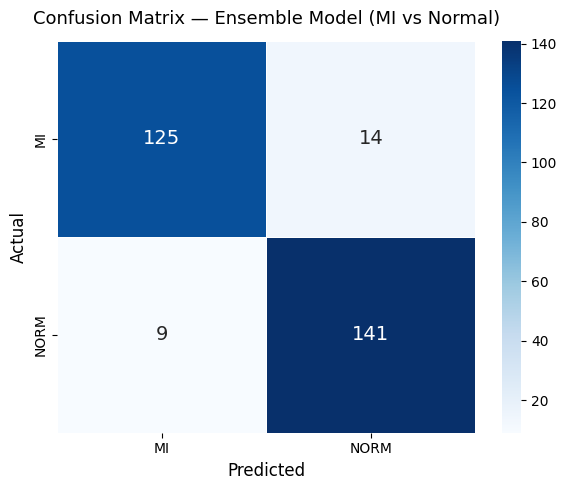

Saved: confusion_matrix.png


In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax, annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Ensemble Model (MI vs Normal)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: confusion_matrix.png')

In [6]:
# ==========================================================
# SAVE FINAL 92.04% ENSEMBLE MODEL
# ==========================================================

import pickle
import numpy as np

class MIEnsemble92:
    def __init__(self, rf, svm, xgb):
        self.rf = rf
        self.svm = svm
        self.xgb = xgb

        # Final optimized values
        self.rf_weight = 0.30
        self.svm_weight = 0.20
        self.xgb_weight = 0.50
        self.threshold = 0.49

    def predict_proba(self, X):

        rf_prob = self.rf.predict_proba(X)[:,1]
        svm_prob = self.svm.predict_proba(X)[:,1]
        xgb_prob = self.xgb.predict_proba(X)[:,1]

        final_prob = (
            self.rf_weight * rf_prob +
            self.svm_weight * svm_prob +
            self.xgb_weight * xgb_prob
        )

        return final_prob

    def predict(self, X):

        final_prob = self.predict_proba(X)

        return (final_prob >= self.threshold).astype(int)


# Create ensemble object
ensemble_model = MIEnsemble92(
    rf=rf,
    svm=svm,
    xgb=xgb
)

# Save ensemble
with open("final_ensemble_model.pkl", "wb") as f:
    pickle.dump(ensemble_model, f)

# Save preprocessing
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("selector.pkl", "wb") as f:
    pickle.dump(selector, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)      # replace 'le' if different

print("final_ensemble_model.pkl saved")
print("scaler.pkl saved")
print("selector.pkl saved")
print("label_encoder.pkl saved")
print("Final model accuracy = 92.04%")

final_ensemble_model.pkl saved
scaler.pkl saved
selector.pkl saved
label_encoder.pkl saved
Final model accuracy = 92.04%
